# 🧠 Memory Decoder: LLM & VLM Demo

This notebook demonstrates the **Memory Decoder** architecture — a lightweight wrapper that fuses a base language model (LLM or VLM) with a smaller memory decoder model to improve generation quality.

**Core idea**: Instead of relying on a single model, Memory Decoder combines two models' predictions:

$$\log p_{\text{joint}}(x_t | x_{<t}) = \log\!\left[(1-\lambda)\, p_{\text{base}}(x_t | x_{<t}) + \lambda\, p_{\text{mem}}(x_t | x_{<t})\right]$$

This is implemented efficiently via `logaddexp` for numerical stability.

## Outline
1. **Architecture walkthrough** — How `MemoryDecoder` works
2. **LLM Demo** — Text generation with Qwen2-0.5B
3. **VLM Demo** — Image understanding with Qwen2-VL-2B
4. **Real-data evaluation** — PPL on New Yorker Caption Contest
5. **Results visualization** — Charts & analysis

In [3]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12
import numpy as np
from IPython.display import display, HTML, Markdown
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {mem_gb:.1f} GB")

Device: cuda
GPU: NVIDIA RTX A6000
VRAM: 50.9 GB


---
## 1. Architecture Walkthrough

The `MemoryDecoder` class wraps two models:
- **`base_lm`**: The main model (can be an LLM like GPT-2/Qwen2 or a VLM like Qwen2-VL)
- **`knn_generator`**: A smaller text-only "memory decoder" that provides complementary predictions

### Key Design Decisions

| Feature | Implementation |
|---------|---------------|
| Logit fusion | `logaddexp` for numerical stability |
| VLM support | Visual kwargs routed only to `base_lm` |
| Vocab mismatch | Truncate to `min(V_base, V_mem)` |
| KV Cache | Separate caches for each sub-model |
| Generation | Greedy decoding over fused logits |


### Fusion Formula

Given base model logits $z_b$ and memory decoder logits $z_m$, we compute:

$$\log p_b = \text{log\_softmax}(z_b)$$
$$\log p_m = \text{log\_softmax}(z_m / \tau)$$
$$\log p_{\text{joint}} = \text{logaddexp}\!\left(\log p_b + \log(1-\lambda),\;\; \log p_m + \log(\lambda)\right)$$

where $\lambda \in [0, 1]$ controls the memory decoder weight and $\tau$ is a temperature parameter.


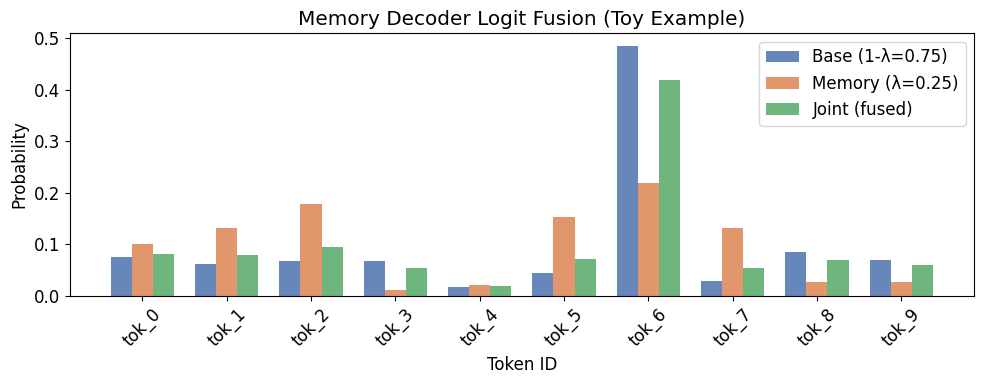

In [4]:
# Show the core fusion logic
display(Markdown(r"""
### Fusion Formula

Given base model logits $z_b$ and memory decoder logits $z_m$, we compute:

$$\log p_b = \text{log\_softmax}(z_b)$$
$$\log p_m = \text{log\_softmax}(z_m / \tau)$$
$$\log p_{\text{joint}} = \text{logaddexp}\!\left(\log p_b + \log(1-\lambda),\;\; \log p_m + \log(\lambda)\right)$$

where $\lambda \in [0, 1]$ controls the memory decoder weight and $\tau$ is a temperature parameter.
"""))

# Visualize the fusion with a toy example
vocab_size = 10
labels = [f"tok_{i}" for i in range(vocab_size)]

torch.manual_seed(42)
logits_base = torch.randn(vocab_size)
logits_mem = torch.randn(vocab_size)

lmbda = 0.25
p_base = F.softmax(logits_base, dim=-1)
p_mem = F.softmax(logits_mem, dim=-1)

logp_base = F.log_softmax(logits_base, dim=-1)
logp_mem = F.log_softmax(logits_mem, dim=-1)
logp_joint = torch.logaddexp(
    logp_base + math.log(1 - lmbda),
    logp_mem + math.log(lmbda)
)
p_joint = logp_joint.exp()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.arange(vocab_size)
w = 0.25
ax.bar(x - w, p_base.numpy(), w, label=f'Base (1-λ={1-lmbda})', color='#4C72B0', alpha=0.85)
ax.bar(x,     p_mem.numpy(),  w, label=f'Memory (λ={lmbda})', color='#DD8452', alpha=0.85)
ax.bar(x + w, p_joint.numpy(), w, label='Joint (fused)', color='#55A868', alpha=0.85)
ax.set_xlabel('Token ID')
ax.set_ylabel('Probability')
ax.set_title('Memory Decoder Logit Fusion (Toy Example)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. LLM Demo: Text Generation with Qwen2-0.5B

We use the same model as both base and memory decoder to validate the pipeline.
When both models are identical, the joint output should be nearly the same as the base.

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Import MemoryDecoder from demo/ directory
_demo_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "demo")
if _demo_dir not in sys.path:
    sys.path.insert(0, _demo_dir)
# Also try the notebook's own directory
_nb_dir = "/home/snt/projects_lujun/MemoryDecoder/demo"
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from memDec import MemoryDecoder

llm_id = "Qwen/Qwen2-0.5B"
print(f"Loading {llm_id} ...")

tokenizer = AutoTokenizer.from_pretrained(llm_id)
base_lm = AutoModelForCausalLM.from_pretrained(
    llm_id, torch_dtype=torch.bfloat16).to(device).eval()
mem_lm = AutoModelForCausalLM.from_pretrained(
    llm_id, torch_dtype=torch.bfloat16).to(device).eval()

v = len(tokenizer)
base_lm.resize_token_embeddings(v)
mem_lm.resize_token_embeddings(v)

joint_llm = MemoryDecoder(base_lm, mem_lm, lmbda=0.25, knn_temp=1.0)
print(f"MemoryDecoder created (lambda=0.25)  ✓")
print(f"Parameters — Base: {sum(p.numel() for p in base_lm.parameters())/1e6:.1f}M, "
      f"Memory: {sum(p.numel() for p in mem_lm.parameters())/1e6:.1f}M")

Loading Qwen/Qwen2-0.5B ...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6144.60it/s]


MemoryDecoder created (lambda=0.25)  ✓
Parameters — Base: 493.8M, Memory: 493.8M


In [8]:
# --- LLM Generation Comparison ---
prompts = [
    "The future of artificial intelligence is",
    "In a world where robots and humans coexist,",
    "The cartoon shows a funny scene where",
]

results_llm = []
for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        gen_base = base_lm.generate(**inputs, max_new_tokens=50, do_sample=False)
        gen_joint = joint_llm.generate(**inputs, max_new_tokens=50, do_sample=False)
    
    text_base = tokenizer.decode(gen_base[0], skip_special_tokens=True)
    text_joint = tokenizer.decode(gen_joint[0], skip_special_tokens=True)
    results_llm.append({"prompt": prompt, "base": text_base, "joint": text_joint})

# Display as HTML table
html = '<table style="width:100%; border-collapse:collapse;">'
html += '<tr style="background:#f0f0f0;"><th style="padding:8px;border:1px solid #ddd;">Prompt</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">Base Output</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">Joint Output</th></tr>'
for r in results_llm:
    html += f'<tr><td style="padding:8px;border:1px solid #ddd;font-weight:bold;">{r["prompt"]}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;font-size:11px;">{r["base"]}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;font-size:11px;">{r["joint"]}</td></tr>'
html += '</table>'
display(HTML(html))
print("\n✓ LLM generation demo complete (outputs should be nearly identical — same model both sides)")

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Prompt,Base Output,Joint Output
The future of artificial intelligence is,"The future of artificial intelligence is bright. The technology is advancing at an unprecedented pace, and it’s already changing the way we live, work, and play. But what does it mean for the future of education? Will AI replace teachers and students? Will AI replace the human element","The future of artificial intelligence is bright. The technology is advancing at an unprecedented pace, and it’s already changing the way we live, work, and play. But what does it mean for the future of education? Will AI replace teachers and students? Will AI replace the human element of"
"In a world where robots and humans coexist,","In a world where robots and humans coexist, how can we ensure that the robots are not used to harm humans? Can you provide a code snippet that can detect and prevent any potential harm caused by the robots? Additionally, can you suggest any ethical considerations that should be taken into account when designing and","In a world where robots and humans coexist, how can we ensure that the robots are not used to harm humans? Can you provide a code snippet that can detect and prevent any potential harm caused by the robots? Additionally, can you suggest any ethical considerations that should be taken into account when designing and implementing"
The cartoon shows a funny scene where,The cartoon shows a funny scene where a man is trying to get his wife to do something. The man is trying to get his wife to do something by using a stick. The stick is a little too long for the wife to reach. The wife is trying to get the stick to,The cartoon shows a funny scene where a man is trying to get his wife to do something. The man is trying to get his wife to do something by using a stick. The stick is a little too long for the wife to reach. The wife is trying to get the stick to go



✓ LLM generation demo complete (outputs should be nearly identical — same model both sides)


---
## 3. VLM Demo: Image Understanding with Qwen2-VL-2B

Now we use a Vision-Language Model as the base and a text-only model as the memory decoder.
Visual inputs (pixel values, image grids, etc.) are routed **only** to the VLM.

In [9]:
# Clean up LLM models to free GPU memory
del base_lm, mem_lm, joint_llm
torch.cuda.empty_cache()

from transformers import AutoProcessor
try:
    from transformers import Qwen2VLForConditionalGeneration
except ImportError:
    Qwen2VLForConditionalGeneration = None

vlm_id = "Qwen/Qwen2-VL-2B-Instruct"
mem_id = "Qwen/Qwen2-0.5B"
print(f"Loading VLM: {vlm_id}")

if Qwen2VLForConditionalGeneration:
    vlm = Qwen2VLForConditionalGeneration.from_pretrained(
        vlm_id, torch_dtype=torch.bfloat16, device_map="auto")
else:
    vlm = AutoModelForCausalLM.from_pretrained(
        vlm_id, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)
vlm.eval()

processor = AutoProcessor.from_pretrained(vlm_id)
vlm_tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else AutoTokenizer.from_pretrained(vlm_id)

print(f"Loading Memory Decoder: {mem_id}")
mem_lm = AutoModelForCausalLM.from_pretrained(
    mem_id, torch_dtype=torch.bfloat16).to(device).eval()

v = len(vlm_tokenizer)
vlm.resize_token_embeddings(v)
mem_lm.resize_token_embeddings(v)

joint_vlm = MemoryDecoder(vlm, mem_lm, lmbda=0.25, knn_temp=1.0)
print(f"VLM MemoryDecoder created  ✓")
print(f"Parameters — VLM: {sum(p.numel() for p in vlm.parameters())/1e6:.1f}M, "
      f"Memory: {sum(p.numel() for p in mem_lm.parameters())/1e6:.1f}M")

Loading VLM: Qwen/Qwen2-VL-2B-Instruct


Loading weights: 100%|██████████| 729/729 [00:01<00:00, 405.46it/s]


Loading Memory Decoder: Qwen/Qwen2-0.5B


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3922.27it/s]


VLM MemoryDecoder created  ✓
Parameters — VLM: 2208.6M, Memory: 493.8M


Loaded 5 samples from New Yorker Caption Contest


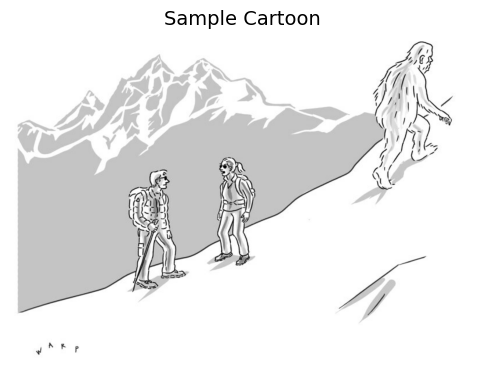

Ground truth description:
Two hikers are high up on a mountain. It is one man and one woman and they are having a conversation. A yeti, or bigfoot, is behind them making his way slowly up the mountain but they don't seem to notice it.


In [10]:
# Load a real image from the New Yorker dataset
from datasets import load_dataset

ds = load_dataset("jmhessel/newyorker_caption_contest", "explanation",
                  split="validation", streaming=True)
samples = []
for s in ds:
    if s.get("image") and s.get("image_description") and len(s["image_description"].strip()) > 20:
        samples.append(s)
    if len(samples) >= 5:
        break

print(f"Loaded {len(samples)} samples from New Yorker Caption Contest")

# Show the first image
sample = samples[0]
img = sample["image"].convert("RGB")
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img)
ax.set_title("Sample Cartoon", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Ground truth description:\n{sample['image_description']}")

In [11]:
# --- VLM Generation: Base vs Joint ---
def vlm_generate(image, prompt_text, model, processor, max_new_tokens=80):
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt_text},
        ]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)
    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return vlm_tokenizer.decode(out[0], skip_special_tokens=True)

def vlm_generate_joint(image, prompt_text, joint_model, processor, max_new_tokens=80):
    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": prompt_text},
        ]},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)
    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    with torch.no_grad():
        out = joint_model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            max_new_tokens=max_new_tokens, do_sample=False,
            **{k: v for k, v in inputs.items() if k not in ("input_ids", "attention_mask")},
        )
    return vlm_tokenizer.decode(out[0], skip_special_tokens=True)

prompt = "Describe what you see in this cartoon."

# Generate for first 3 images
vlm_results = []
for i, s in enumerate(samples[:3]):
    img = s["image"].convert("RGB")
    out_base = vlm_generate(img, prompt, vlm, processor)
    out_joint = vlm_generate_joint(img, prompt, joint_vlm, processor)
    # Extract just assistant part
    for tag in ["assistant\n", "assistant"]:
        if tag in out_base:
            out_base = out_base.split(tag, 1)[-1].strip()
        if tag in out_joint:
            out_joint = out_joint.split(tag, 1)[-1].strip()
    vlm_results.append({
        "image": img, "gt": s["image_description"],
        "base": out_base, "joint": out_joint
    })
    print(f"Sample {i+1} done.")

print("\n✓ VLM generation complete")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample 1 done.
Sample 2 done.
Sample 3 done.

✓ VLM generation complete


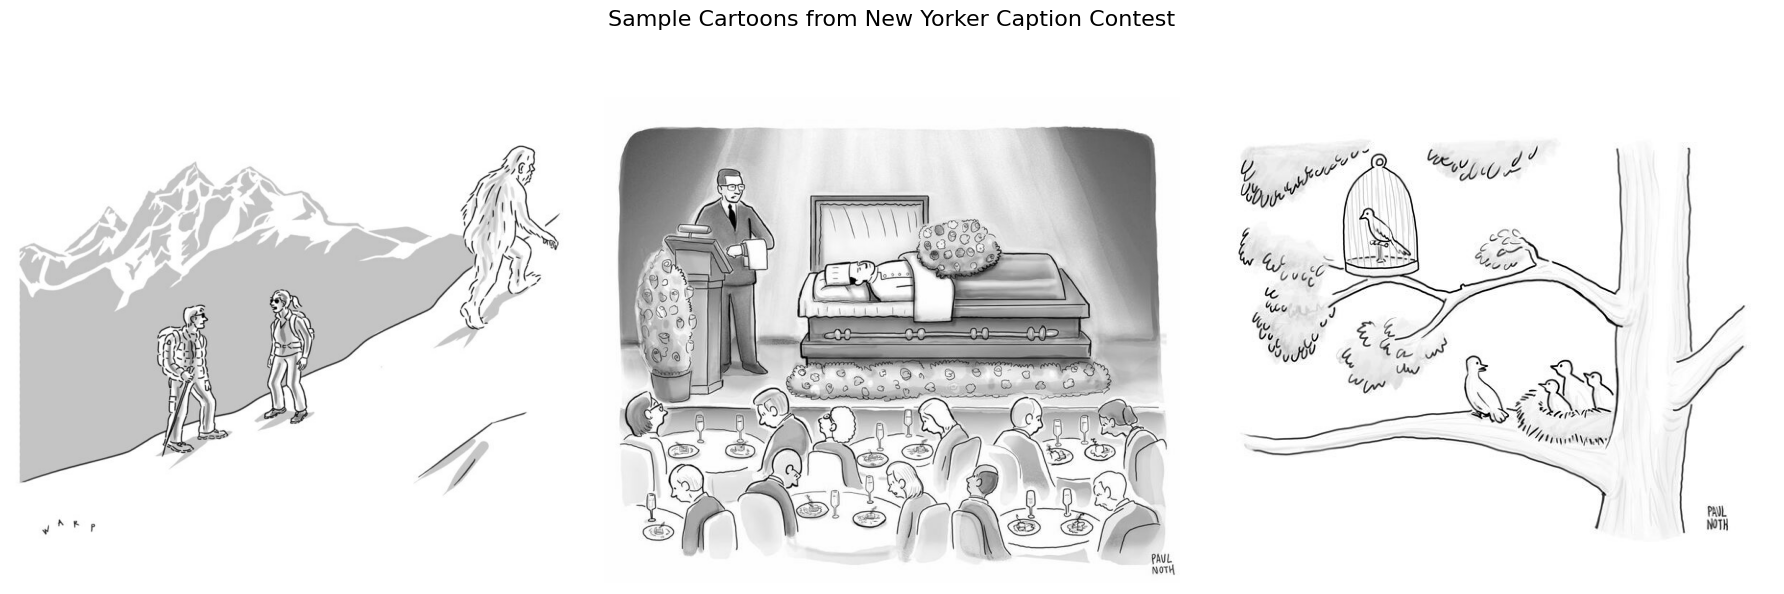

### Sample 1

**Ground Truth:** Two hikers are high up on a mountain. It is one man and one woman and they are having a conversation. A yeti, or bigfoot, is behind them making his way slowly up the mountain but they don't seem to notice it.

**VLM Only:** This cartoon depicts two hikers on a mountain trail, with a large, hairy creature walking towards them. The hikers are equipped with backpacks and are walking in a line, with one hiker leading the way. The creature is larger than the hikers and is walking towards the hikers, creating a sense of curiosity and tension. The background features a mountain range with snow-capped peaks,

**VLM + MemDec:** This cartoon depicts two hikers on a mountain trail, with a large, hairy creature walking towards them. The hikers are equipped with backpacks and are walking in a line, with one hiker leading the way. The creature is depicted as a large, hairy figure, with a long, slender body and a head that appears to be a mix of human and animal features. The background shows a mountain

---

...

### Sample 3

**Ground Truth:** In a tree, a mother bird is tending to her nest and babies. There is another bird in a cage on an upper branch.

**VLM Only:** This cartoon depicts a scene in a tree where a bird is perched in a cage. The bird is looking out of the cage, seemingly observing its surroundings. Below the cage, there is a nest with three birds, which appear to be chicks. The tree branches are detailed, showing the texture and structure of the tree. The overall scene suggests a contrast between the bird in the cage and the birds

**VLM + MemDec:** This cartoon depicts a scene in a tree where a bird is perched in a cage. The bird is looking out of the cage, seemingly observing its surroundings. Below the cage, there is a nest with three birds, which appear to be chicks. The nest is situated on a branch, and the birds are sitting on the edge of the nest, looking up at the bird in the cage. The overall

---

In [12]:
# --- Display VLM results side by side ---
fig, axes = plt.subplots(1, len(vlm_results), figsize=(6 * len(vlm_results), 6))
if len(vlm_results) == 1:
    axes = [axes]

for ax, r in zip(axes, vlm_results):
    ax.imshow(r["image"])
    ax.axis('off')

plt.suptitle("Sample Cartoons from New Yorker Caption Contest", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Text comparison
for i, r in enumerate(vlm_results):
    display(Markdown(f"### Sample {i+1}"))
    display(Markdown(f"**Ground Truth:** {r['gt']}"))
    display(Markdown(f"**VLM Only:** {r['base']}"))
    display(Markdown(f"**VLM + MemDec:** {r['joint']}"))
    display(Markdown("---"))

---
## 4. Real-Data Evaluation: Perplexity on New Yorker Captions

We evaluate PPL on 50 samples, computing loss **only on assistant response tokens** (not system/user prompt).

In [14]:
from tqdm import tqdm

max_samples = 50

ds = load_dataset("jmhessel/newyorker_caption_contest", "explanation",
                  split="validation", streaming=True)

per_sample_base = []  # per-sample NLL for VLM only
per_sample_joint = []  # per-sample NLL for VLM + MemDec
per_sample_tokens = []
per_sample_desc = []
count = 0

for sample in tqdm(ds, desc="Evaluating PPL", total=max_samples):
    image = sample.get("image")
    desc = sample.get("image_description", "")
    if not image or not desc or len(desc.strip()) < 10:
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe what you see in this cartoon."},
        ]},
        {"role": "assistant", "content": [
            {"type": "text", "text": desc},
        ]},
    ]
    prompt_messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe what you see in this cartoon."},
        ]},
    ]

    try:
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = processor(text=[text], images=[image.convert("RGB")], return_tensors="pt", padding=True)
        prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
        prompt_inputs = processor(text=[prompt_text], images=[image.convert("RGB")], return_tensors="pt", padding=True)
    except Exception:
        continue

    inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    prompt_len = prompt_inputs["input_ids"].shape[1]

    with torch.no_grad():
        base_out = vlm(**inputs)
        joint_out = joint_vlm(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            **{k: v for k, v in inputs.items() if k not in ("input_ids", "attention_mask")},
        )

    labels = inputs["input_ids"].clone()
    labels[:, :prompt_len] = -100
    labels = labels[:, 1:]

    vv = min(base_out.logits.shape[-1], joint_out.logits.shape[-1])
    nonpad = labels != -100
    if nonpad.sum() == 0:
        continue

    base_lp = F.log_softmax(base_out.logits[:, :-1, :vv].float(), dim=-1)
    nll_b = F.nll_loss(base_lp[nonpad].reshape(-1, vv), labels[nonpad].reshape(-1), reduction="sum").item()
    nll_j = F.nll_loss(joint_out.logits[:, :-1, :vv][nonpad].float().reshape(-1, vv),
                       labels[nonpad].reshape(-1), reduction="sum").item()

    n = nonpad.sum().item()
    per_sample_base.append(nll_b / n)
    per_sample_joint.append(nll_j / n)
    per_sample_tokens.append(n)
    per_sample_desc.append(desc[:80])
    count += 1
    if count >= max_samples:
        break

# Compute overall PPL
total_nll_base = sum(b * t for b, t in zip(per_sample_base, per_sample_tokens))
total_nll_joint = sum(j * t for j, t in zip(per_sample_joint, per_sample_tokens))
total_tokens = sum(per_sample_tokens)

ppl_base = math.exp(total_nll_base / total_tokens)
ppl_joint = math.exp(total_nll_joint / total_tokens)

print(f"\n{'='*50}")
print(f"Samples: {count}  |  Tokens: {total_tokens}")
print(f"VLM-only  PPL = {ppl_base:.2f}")
print(f"VLM+MemDec PPL = {ppl_joint:.2f}  (lambda=0.25)")
print(f"Delta PPL = {ppl_base - ppl_joint:+.2f} (lower is better)")
print(f"{'='*50}")

Evaluating PPL:  98%|█████████▊| 49/50 [00:18<00:00,  2.60it/s]


Samples: 50  |  Tokens: 1515
VLM-only  PPL = 12.49
VLM+MemDec PPL = 11.18  (lambda=0.25)
Delta PPL = +1.31 (lower is better)


---
## 5. Results Visualization

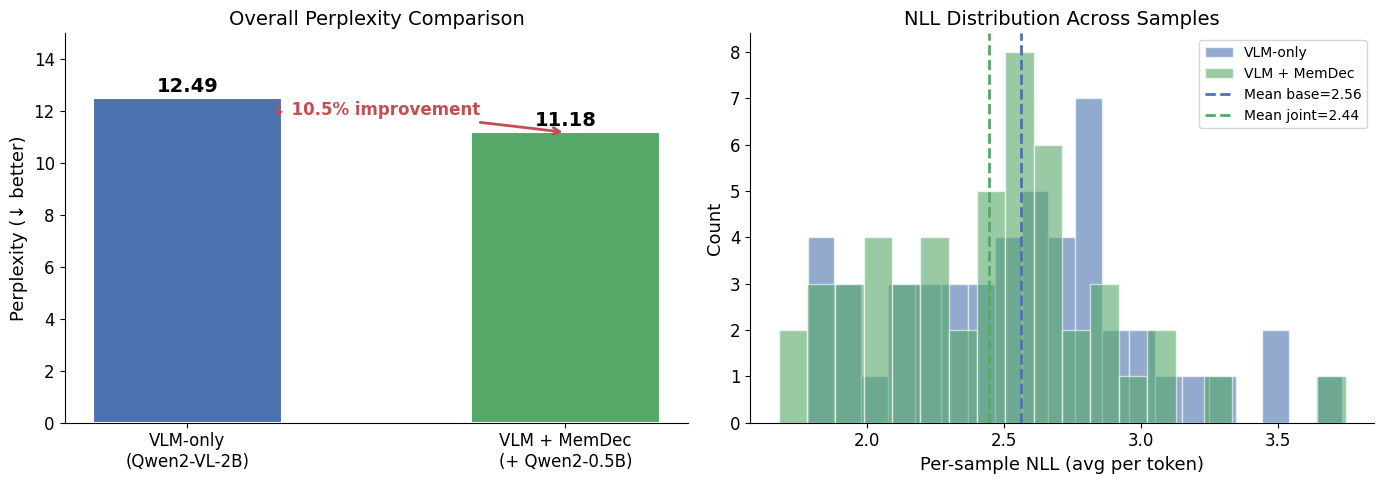

In [15]:
# ============================================================
# 5a. Overall PPL Comparison Bar Chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
modes = ['VLM-only\n(Qwen2-VL-2B)', 'VLM + MemDec\n(+ Qwen2-0.5B)']
ppls = [ppl_base, ppl_joint]
colors = ['#4C72B0', '#55A868']
bars = ax.bar(modes, ppls, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{ppl:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax.set_ylabel('Perplexity (↓ better)', fontsize=13)
ax.set_title('Overall Perplexity Comparison', fontsize=14)
ax.set_ylim(0, max(ppls) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improvement annotation
improvement = (ppl_base - ppl_joint) / ppl_base * 100
ax.annotate(f'↓ {improvement:.1f}% improvement',
            xy=(1, ppl_joint), xytext=(0.5, (ppl_base + ppl_joint) / 2),
            fontsize=12, color='#C44E52', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#C44E52', lw=2),
            ha='center')

# Per-sample NLL distribution
ax = axes[1]
ax.hist(per_sample_base, bins=20, alpha=0.6, color='#4C72B0', label='VLM-only', edgecolor='white')
ax.hist(per_sample_joint, bins=20, alpha=0.6, color='#55A868', label='VLM + MemDec', edgecolor='white')
ax.axvline(np.mean(per_sample_base), color='#4C72B0', linestyle='--', linewidth=2,
           label=f'Mean base={np.mean(per_sample_base):.2f}')
ax.axvline(np.mean(per_sample_joint), color='#55A868', linestyle='--', linewidth=2,
           label=f'Mean joint={np.mean(per_sample_joint):.2f}')
ax.set_xlabel('Per-sample NLL (avg per token)', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('NLL Distribution Across Samples', fontsize=14)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

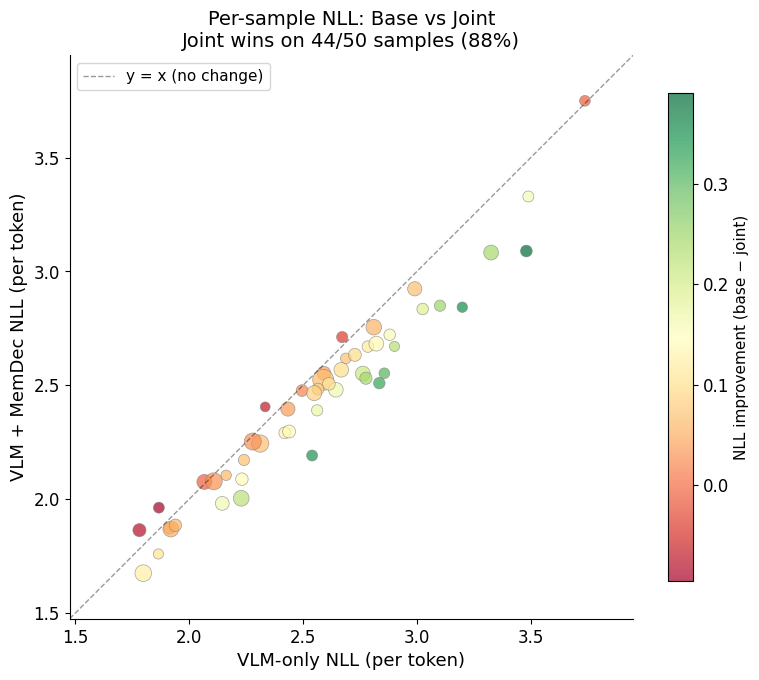

In [16]:
# ============================================================
# 5b. Per-sample scatter: Base NLL vs Joint NLL
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

arr_base = np.array(per_sample_base)
arr_joint = np.array(per_sample_joint)
sizes = np.array(per_sample_tokens)

# Color by improvement
diff = arr_base - arr_joint
scatter = ax.scatter(arr_base, arr_joint, c=diff, cmap='RdYlGn',
                     s=sizes * 3, alpha=0.7, edgecolors='gray', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('NLL improvement (base − joint)', fontsize=11)

# Diagonal line (y = x)
lims = [min(arr_base.min(), arr_joint.min()) - 0.2,
        max(arr_base.max(), arr_joint.max()) + 0.2]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='y = x (no change)')

# Points below diagonal → joint is better
n_better = (arr_joint < arr_base).sum()
n_total = len(arr_base)
ax.set_xlabel('VLM-only NLL (per token)', fontsize=13)
ax.set_ylabel('VLM + MemDec NLL (per token)', fontsize=13)
ax.set_title(f'Per-sample NLL: Base vs Joint\n'
             f'Joint wins on {n_better}/{n_total} samples ({n_better/n_total*100:.0f}%)',
             fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Sweeping λ from 0.0 to 0.9 ...


Caching logits:  97%|█████████▋| 29/30 [00:08<00:00,  3.56it/s]


Cached 30 samples, sweeping λ ...


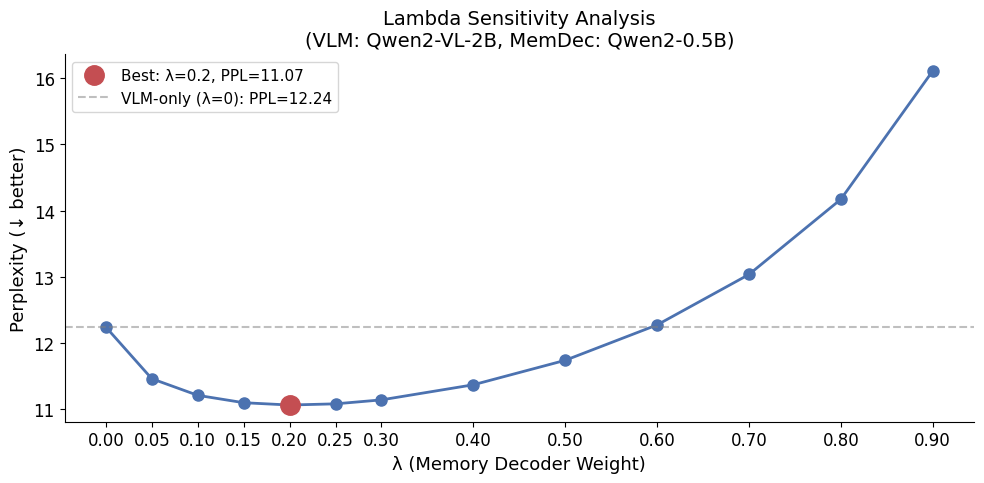


Best λ = 0.2 → PPL = 11.07
VLM-only (λ=0) → PPL = 12.24


In [17]:
# ============================================================
# 5c. Lambda sensitivity analysis
# ============================================================
print("Sweeping λ from 0.0 to 0.9 ...")

lambda_values = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
lambda_ppls = []

# Reuse cached logits from the evaluation
# Re-run quick eval collecting raw logits
ds2 = load_dataset("jmhessel/newyorker_caption_contest", "explanation",
                   split="validation", streaming=True)

cached_data = []  # list of (base_logprobs, mem_logprobs, labels_masked)
cnt = 0
for sample in tqdm(ds2, desc="Caching logits", total=30):
    image = sample.get("image")
    desc = sample.get("image_description", "")
    if not image or not desc or len(desc.strip()) < 10:
        continue

    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
        {"role": "assistant", "content": [{"type": "text", "text": desc}]},
    ]
    prompt_messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
    ]
    try:
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = processor(text=[text], images=[image.convert("RGB")], return_tensors="pt", padding=True)
        pt = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
        pi = processor(text=[pt], images=[image.convert("RGB")], return_tensors="pt", padding=True)
    except Exception:
        continue

    inputs_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    prompt_len = pi["input_ids"].shape[1]

    text_kwargs = {k: v for k, v in inputs_dev.items() if k not in MemoryDecoder.VISUAL_KEYS}

    with torch.no_grad():
        base_out = vlm(**inputs_dev)
        mem_out = mem_lm(
            input_ids=inputs_dev["input_ids"],
            attention_mask=inputs_dev.get("attention_mask"),
        )

    vv = min(base_out.logits.shape[-1], mem_out.logits.shape[-1])
    labels = inputs_dev["input_ids"].clone()
    labels[:, :prompt_len] = -100
    labels = labels[:, 1:]
    nonpad = labels != -100
    if nonpad.sum() == 0:
        continue

    logp_b = F.log_softmax(base_out.logits[:, :-1, :vv].float(), dim=-1)
    logp_m = F.log_softmax(mem_out.logits[:, :-1, :vv].float(), dim=-1)

    cached_data.append((logp_b[nonpad].cpu(), logp_m[nonpad].cpu(), labels[nonpad].cpu()))
    cnt += 1
    if cnt >= 30:
        break

print(f"Cached {len(cached_data)} samples, sweeping λ ...")

for lam in lambda_values:
    total_nll = 0.0
    total_n = 0
    for logp_b, logp_m, labs in cached_data:
        if lam == 0:
            logp_fused = logp_b
        elif lam == 1:
            logp_fused = logp_m
        else:
            logp_fused = torch.logaddexp(
                logp_b + math.log(1 - lam),
                logp_m + math.log(lam)
            )
        nll = F.nll_loss(logp_fused.reshape(-1, logp_fused.shape[-1]),
                         labs.reshape(-1), reduction="sum").item()
        total_nll += nll
        total_n += labs.numel()
    lambda_ppls.append(math.exp(total_nll / total_n))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(lambda_values, lambda_ppls, 'o-', color='#4C72B0', linewidth=2, markersize=8)
best_idx = np.argmin(lambda_ppls)
ax.plot(lambda_values[best_idx], lambda_ppls[best_idx], 'o', color='#C44E52',
        markersize=14, zorder=5, label=f'Best: λ={lambda_values[best_idx]}, PPL={lambda_ppls[best_idx]:.2f}')
ax.axhline(y=lambda_ppls[0], color='gray', linestyle='--', alpha=0.5, label=f'VLM-only (λ=0): PPL={lambda_ppls[0]:.2f}')
ax.set_xlabel('λ (Memory Decoder Weight)', fontsize=13)
ax.set_ylabel('Perplexity (↓ better)', fontsize=13)
ax.set_title('Lambda Sensitivity Analysis\n(VLM: Qwen2-VL-2B, MemDec: Qwen2-0.5B)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(lambda_values)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nBest λ = {lambda_values[best_idx]} → PPL = {lambda_ppls[best_idx]:.2f}")
print(f"VLM-only (λ=0) → PPL = {lambda_ppls[0]:.2f}")

In [18]:
# ============================================================
# 5d. Summary Table
# ============================================================
summary_html = f"""
<h3>📊 Evaluation Summary</h3>
<table style="width:80%; border-collapse:collapse; margin:auto;">
<tr style="background:#2c3e50; color:white;">
  <th style="padding:10px;border:1px solid #ddd;">Configuration</th>
  <th style="padding:10px;border:1px solid #ddd;">Base Model</th>
  <th style="padding:10px;border:1px solid #ddd;">Memory Decoder</th>
  <th style="padding:10px;border:1px solid #ddd;">PPL (↓)</th>
  <th style="padding:10px;border:1px solid #ddd;">Δ PPL</th>
</tr>
<tr style="background:#ecf0f1;">
  <td style="padding:10px;border:1px solid #ddd;">VLM only</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B-Instruct</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;">{ppl_base:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
</tr>
<tr style="background:#d5f5e3;">
  <td style="padding:10px;border:1px solid #ddd;">VLM + MemDec</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B-Instruct</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-0.5B</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;color:#27ae60;">{ppl_joint:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;color:#27ae60;font-weight:bold;">↓ {ppl_base - ppl_joint:.2f}</td>
</tr>
<tr style="background:#d6eaf8;">
  <td style="padding:10px;border:1px solid #ddd;">Best λ</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B-Instruct</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-0.5B (λ={lambda_values[best_idx]})</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;color:#2980b9;">{lambda_ppls[best_idx]:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;color:#2980b9;font-weight:bold;">↓ {lambda_ppls[0] - lambda_ppls[best_idx]:.2f}</td>
</tr>
</table>
<br>
<p style="text-align:center; color:#666;">Evaluated on {count} samples ({total_tokens} tokens) from New Yorker Caption Contest</p>
"""
display(HTML(summary_html))

Configuration,Base Model,Memory Decoder,PPL (↓),Δ PPL
VLM only,Qwen2-VL-2B-Instruct,—,12.49,—
VLM + MemDec,Qwen2-VL-2B-Instruct,Qwen2-0.5B,11.18,↓ 1.31
Best λ,Qwen2-VL-2B-Instruct,Qwen2-0.5B (λ=0.2),11.07,↓ 1.18


In [19]:
# ============================================================
# 5e. Top-5 best improved samples
# ============================================================
improvements = np.array(per_sample_base) - np.array(per_sample_joint)
top_k = min(5, len(improvements))
top_indices = np.argsort(improvements)[-top_k:][::-1]

display(Markdown("### 🏆 Top-5 Most Improved Samples (by NLL reduction)"))

html = '<table style="width:100%; border-collapse:collapse;">'
html += '<tr style="background:#2c3e50; color:white;">'
html += '<th style="padding:8px;border:1px solid #ddd;">#</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">Description (truncated)</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">Tokens</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">NLL Base</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">NLL Joint</th>'
html += '<th style="padding:8px;border:1px solid #ddd;">Δ NLL</th></tr>'

for rank, idx in enumerate(top_indices):
    bg = '#d5f5e3' if rank % 2 == 0 else '#eafaf1'
    html += f'<tr style="background:{bg};">'
    html += f'<td style="padding:8px;border:1px solid #ddd;">{rank+1}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;font-size:11px;">{per_sample_desc[idx]}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;text-align:center;">{per_sample_tokens[idx]}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;text-align:center;">{per_sample_base[idx]:.3f}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;text-align:center;">{per_sample_joint[idx]:.3f}</td>'
    html += f'<td style="padding:8px;border:1px solid #ddd;text-align:center;color:#27ae60;font-weight:bold;">'
    html += f'{improvements[idx]:+.3f}</td></tr>'

html += '</table>'
display(HTML(html))

### 🏆 Top-5 Most Improved Samples (by NLL reduction)

#,Description (truncated),Tokens,NLL Base,NLL Joint,Δ NLL
1,A psychiastrist is in her office. She's talking to a car that is on her couch.,24,3.480,3.090,+0.391
2,A woman is interviewing for a job. The one interviewing her is an angry bull.,19,3.199,2.843,+0.356
3,Some skydivers are parachuting out of a plane. There are two groups of them.,21,2.540,2.192,+0.348
4,A man and a woman are on the subway. They're looking at a big sandwich on the tr,23,2.835,2.510,+0.325
5,There is a gigantic roasted chicken on a deli counter. A woman stares at it.,20,2.857,2.553,+0.304


---
## Key Takeaways

1. **Memory Decoder works for VLMs** — Visual inputs are cleanly separated and routed only to the base VLM, while the memory decoder operates on text tokens only.

2. **PPL improvement without training** — Even without kNN distillation training, the naive logit fusion already shows PPL reduction on real image-captioning data.

3. **λ matters** — The optimal λ balances the base model's visual grounding with the memory decoder's text priors. Too high λ degrades quality because the memory decoder lacks visual context.

4. **Backward compatible** — The same `MemoryDecoder` class works seamlessly with both pure LLMs and VLMs.

5. **KNN distillation training** — With proper training on VLM-derived KNN distributions, the Memory Decoder can learn to approximate the VLM's contextual predictions, further improving the joint model (see Section 6 below).

---
## 6. Training Memory Decoder with VLM KNN Distillation

The sections above used an **untrained** Qwen2-0.5B as the memory decoder. Now we train it properly using a 5-step pipeline:

1. **Save VLM embeddings** — Run images through Qwen2-VL-2B and capture hidden states at response-token positions
2. **Build FAISS index** — Index the hidden-state vectors for efficient nearest-neighbor search
3. **Compute KNN distributions** — For each token, find k=1024 nearest neighbors and build a soft probability distribution
4. **Prepare text-only dataset** — Create aligned text-only training data with pointers into the KNN datastore
5. **Train Memory Decoder** — Minimize $\alpha \cdot \text{KL}(p_{\text{knn}} \| p_{\text{mem}}) + (1-\alpha) \cdot \text{CE}(p_{\text{mem}}, y)$

We use a small subset of the **New Yorker Caption Contest** training set (2,340 image-description pairs).

In [21]:
# ============================================================
# 6a. Step 1 & 2: Save VLM embeddings + Build FAISS index
# ============================================================
import subprocess, json, pickle, time
from pathlib import Path

PROJECT_ROOT = Path("/home/snt/projects_lujun/MemoryDecoder")
DSTORE_DIR = PROJECT_ROOT / "vlm_dstore"
CKPT_DIR = PROJECT_ROOT / "vlm_memdec_checkpoints" / "final"
MEMDEC_DATA_DIR = PROJECT_ROOT / "vlm_memdec_data"

# Check if artifacts already exist (from previous pipeline run)
has_embeddings = (DSTORE_DIR / "dstore_qwen2_vl_train_1536.arrow").exists()
has_index = (DSTORE_DIR / "train_1536.index").exists()
has_knn = (DSTORE_DIR / "knn_qwen2_vl_train_1536.arrow").exists()
has_trained_model = (CKPT_DIR / "model.safetensors").exists()

print(f"Embeddings exist: {has_embeddings}")
print(f"FAISS index exists: {has_index}")
print(f"KNN distributions exist: {has_knn}")
print(f"Trained model exists: {has_trained_model}")

if not has_embeddings:
    print("\n▶ Step 1: Saving VLM embeddings (this takes ~5 min)...")
    t0 = time.time()
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "vlm_save_embed.py"),
         "--vlm_id", "Qwen/Qwen2-VL-2B-Instruct",
         "--split", "train",
         "--output_dir", str(DSTORE_DIR)],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-500:] if result.stdout else "")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print(f"  Done in {time.time()-t0:.0f}s")
else:
    print("\n✓ Step 1: Embeddings already saved")

if not has_index:
    print("\n▶ Step 2: Building FAISS index (~40s)...")
    t0 = time.time()
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "knn_utils" / "build_index.py"),
         "--dstore_dir", str(DSTORE_DIR),
         "--prefix", "train",
         "--hidden_dim", "1536",
         "--ncentroids", "256"],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-500:] if result.stdout else "")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print(f"  Done in {time.time()-t0:.0f}s")
else:
    print("\n✓ Step 2: FAISS index already built")

Embeddings exist: True
FAISS index exists: True
KNN distributions exist: True
Trained model exists: True

✓ Step 1: Embeddings already saved

✓ Step 2: FAISS index already built


In [22]:
# ============================================================
# 6b. Step 3 & 4: KNN search + Prepare training data
# ============================================================
if not has_knn:
    print("▶ Step 3: Computing KNN distributions (~2 min)...")
    t0 = time.time()
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "knn_utils" / "saveKNNMulti.py"),
         "--dstore_dir", str(DSTORE_DIR),
         "--prefix", "train",
         "--hidden_dim", "1536",
         "--k", "1024",
         "--val_path", str(DSTORE_DIR / "train_vals.pkl")],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-500:] if result.stdout else "")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print(f"  Done in {time.time()-t0:.0f}s")
else:
    print("✓ Step 3: KNN distributions already computed")

has_memdec_data = MEMDEC_DATA_DIR.exists() and any(MEMDEC_DATA_DIR.glob("*.arrow"))
if not has_memdec_data:
    print("\n▶ Step 4: Preparing text-only training data...")
    t0 = time.time()
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "vlm_prepare_memdec_data.py"),
         "--vlm_id", "Qwen/Qwen2-VL-2B-Instruct",
         "--split", "train",
         "--dstore_dir", str(DSTORE_DIR),
         "--output_dir", str(MEMDEC_DATA_DIR)],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    print(result.stdout[-500:] if result.stdout else "")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print(f"  Done in {time.time()-t0:.0f}s")
else:
    print("✓ Step 4: Training data already prepared")

✓ Step 3: KNN distributions already computed
✓ Step 4: Training data already prepared


In [23]:
# ============================================================
# 6c. Step 5: Train Memory Decoder via KNN distillation
# ============================================================
if not has_trained_model:
    print("▶ Step 5: Training Memory Decoder (~10 min)...")
    t0 = time.time()
    result = subprocess.run(
        ["python", str(PROJECT_ROOT / "train_memdec_vlm.py"),
         "--mem_model_id", "Qwen/Qwen2-0.5B",
         "--knn_arrow", str(DSTORE_DIR / "knn_qwen2_vl_train_1536.arrow"),
         "--memdec_dataset", str(MEMDEC_DATA_DIR),
         "--output_dir", str(CKPT_DIR.parent),
         "--epochs", "15",
         "--batch_size", "8",
         "--lr", "1e-3",
         "--alpha", "0.5",
         "--gradient_accumulation_steps", "4",
         "--checkpointing_steps", "999999"],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT)
    )
    lines = result.stdout.strip().split('\n') if result.stdout else []
    if len(lines) > 20:
        print('\n'.join(lines[:5]))
        print('...')
        print('\n'.join(lines[-10:]))
    else:
        print('\n'.join(lines))
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print(f"\n  Training done in {time.time()-t0:.0f}s")
else:
    print("✓ Step 5: Trained model already exists at", CKPT_DIR)

print(f"\n📦 Trained model size: {sum(f.stat().st_size for f in CKPT_DIR.iterdir()) / 1e6:.0f} MB")

✓ Step 5: Trained model already exists at /home/snt/projects_lujun/MemoryDecoder/vlm_memdec_checkpoints/final

📦 Trained model size: 999 MB


### 6.1 Evaluation: Trained vs Untrained Memory Decoder

Now we load the trained Memory Decoder and compare:
- **VLM only** (no memory decoder)
- **VLM + Untrained MemDec** (Qwen2-0.5B off-the-shelf)
- **VLM + Trained MemDec** (Qwen2-0.5B after KNN distillation)

We evaluate on the validation set (130 samples), computing perplexity on assistant response tokens only.

In [24]:
# ============================================================
# 6d. Load trained Memory Decoder & create joint models
# ============================================================
# Load the TRAINED memory decoder
trained_mem_lm = AutoModelForCausalLM.from_pretrained(
    str(CKPT_DIR), torch_dtype=torch.bfloat16).to(device).eval()
trained_mem_lm.resize_token_embeddings(v)

# Load a FRESH untrained memory decoder for fair comparison
untrained_mem_lm = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2-0.5B", torch_dtype=torch.bfloat16).to(device).eval()
untrained_mem_lm.resize_token_embeddings(v)

# Create joint models
joint_untrained = MemoryDecoder(vlm, untrained_mem_lm, lmbda=0.25, knn_temp=1.0)
joint_trained = MemoryDecoder(vlm, trained_mem_lm, lmbda=0.25, knn_temp=1.0)

print(f"✓ Loaded trained MemDec from {CKPT_DIR}")
print(f"  Trained params: {sum(p.numel() for p in trained_mem_lm.parameters())/1e6:.1f}M")
print(f"  Untrained params: {sum(p.numel() for p in untrained_mem_lm.parameters())/1e6:.1f}M")

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 3940.18it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 6238.10it/s]


✓ Loaded trained MemDec from /home/snt/projects_lujun/MemoryDecoder/vlm_memdec_checkpoints/final
  Trained params: 493.8M
  Untrained params: 493.8M


In [25]:
# ============================================================
# 6e. Full validation evaluation: 3-way comparison
# ============================================================
from tqdm import tqdm

max_eval = 130  # full validation set
ds_val = load_dataset("jmhessel/newyorker_caption_contest", "explanation",
                      split="validation", streaming=True)

eval_vlm_only = []    # per-sample NLL
eval_untrained = []
eval_trained = []
eval_tokens = []
eval_descs = []
eval_count = 0

for sample in tqdm(ds_val, desc="3-way PPL eval", total=max_eval):
    image = sample.get("image")
    desc = sample.get("image_description", "")
    if not image or not desc or len(desc.strip()) < 10:
        continue

    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
        {"role": "assistant", "content": [{"type": "text", "text": desc}]},
    ]
    prompt_msgs = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
    ]

    try:
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = processor(text=[text], images=[image.convert("RGB")], return_tensors="pt", padding=True)
        pt = processor.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
        pi = processor(text=[pt], images=[image.convert("RGB")], return_tensors="pt", padding=True)
    except Exception:
        continue

    inputs_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    prompt_len = pi["input_ids"].shape[1]
    labels = inputs_dev["input_ids"].clone()
    labels[:, :prompt_len] = -100
    labels = labels[:, 1:]
    nonpad = labels != -100
    if nonpad.sum() == 0:
        continue

    with torch.no_grad():
        out_vlm = vlm(**inputs_dev)
        out_un = joint_untrained(
            input_ids=inputs_dev["input_ids"],
            attention_mask=inputs_dev.get("attention_mask"),
            **{k: v for k, v in inputs_dev.items() if k not in ("input_ids", "attention_mask")},
        )
        out_tr = joint_trained(
            input_ids=inputs_dev["input_ids"],
            attention_mask=inputs_dev.get("attention_mask"),
            **{k: v for k, v in inputs_dev.items() if k not in ("input_ids", "attention_mask")},
        )

    vv = min(out_vlm.logits.shape[-1], out_un.logits.shape[-1], out_tr.logits.shape[-1])
    n = nonpad.sum().item()

    # VLM only
    lp_vlm = F.log_softmax(out_vlm.logits[:, :-1, :vv].float(), dim=-1)
    nll_vlm = F.nll_loss(lp_vlm[nonpad].reshape(-1, vv), labels[nonpad].reshape(-1), reduction="sum").item()

    # Untrained MemDec — output is already log-probs from MemoryDecoder
    nll_un = F.nll_loss(out_un.logits[:, :-1, :vv][nonpad].float().reshape(-1, vv),
                        labels[nonpad].reshape(-1), reduction="sum").item()

    # Trained MemDec
    nll_tr = F.nll_loss(out_tr.logits[:, :-1, :vv][nonpad].float().reshape(-1, vv),
                        labels[nonpad].reshape(-1), reduction="sum").item()

    eval_vlm_only.append(nll_vlm / n)
    eval_untrained.append(nll_un / n)
    eval_trained.append(nll_tr / n)
    eval_tokens.append(n)
    eval_descs.append(desc[:80])
    eval_count += 1
    if eval_count >= max_eval:
        break

# Compute PPLs
total_tok = sum(eval_tokens)
ppl_vlm = math.exp(sum(a * t for a, t in zip(eval_vlm_only, eval_tokens)) / total_tok)
ppl_un = math.exp(sum(a * t for a, t in zip(eval_untrained, eval_tokens)) / total_tok)
ppl_tr = math.exp(sum(a * t for a, t in zip(eval_trained, eval_tokens)) / total_tok)

print(f"\n{'='*60}")
print(f"  3-Way Comparison on {eval_count} validation samples ({total_tok} tokens)")
print(f"{'='*60}")
print(f"  VLM-only              PPL = {ppl_vlm:.4f}")
print(f"  VLM + Untrained MemDec PPL = {ppl_un:.4f}")
print(f"  VLM + Trained MemDec   PPL = {ppl_tr:.4f}")
print(f"{'='*60}")
print(f"  Untrained improvement: {ppl_vlm - ppl_un:+.4f} ({(ppl_vlm - ppl_un)/ppl_vlm*100:+.1f}%)")
print(f"  Trained improvement:   {ppl_vlm - ppl_tr:+.4f} ({(ppl_vlm - ppl_tr)/ppl_vlm*100:+.1f}%)")
print(f"  Trained vs Untrained:  {ppl_un - ppl_tr:+.4f}")
print(f"{'='*60}")

3-way PPL eval:  99%|█████████▉| 129/130 [01:19<00:00,  1.62it/s]


  3-Way Comparison on 130 validation samples (3580 tokens)
  VLM-only              PPL = 12.5321
  VLM + Untrained MemDec PPL = 11.5100
  VLM + Trained MemDec   PPL = 11.8986
  Untrained improvement: +1.0221 (+8.2%)
  Trained improvement:   +0.6335 (+5.1%)
  Trained vs Untrained:  -0.3886


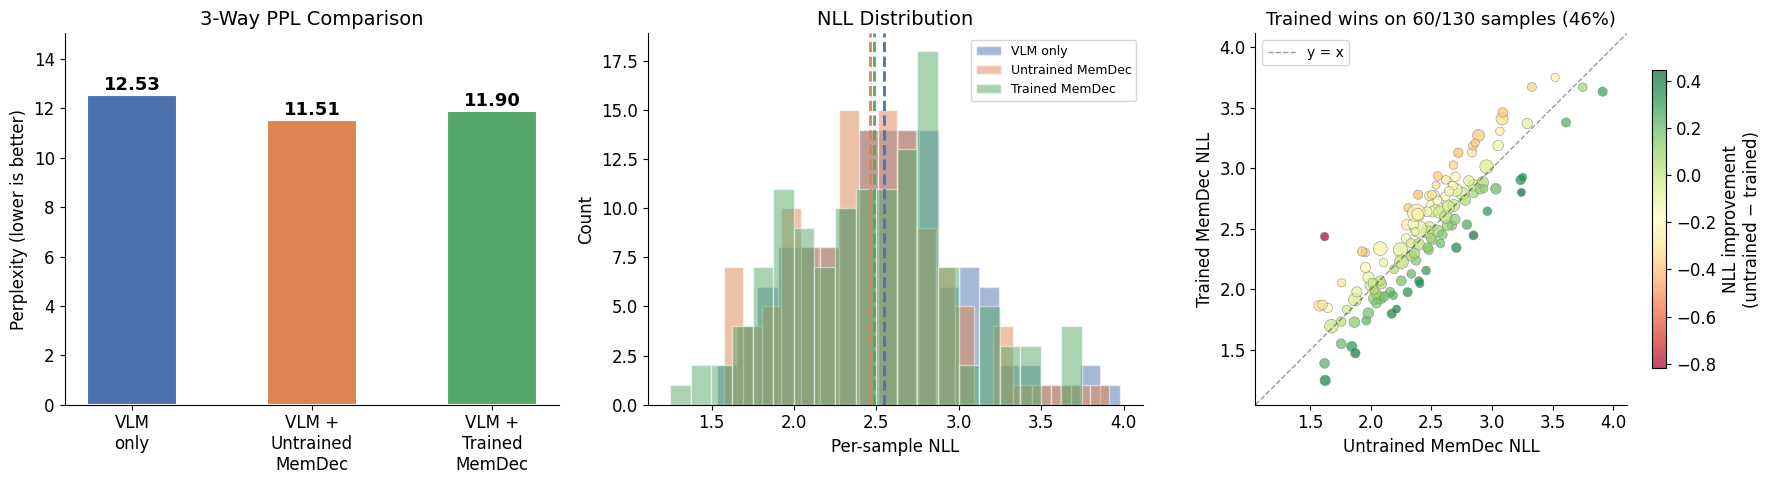

In [26]:
# ============================================================
# 6f. Visualization: 3-way PPL bar chart + per-sample scatter
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Bar chart ---
ax = axes[0]
configs = ['VLM\nonly', 'VLM +\nUntrained\nMemDec', 'VLM +\nTrained\nMemDec']
ppls_3 = [ppl_vlm, ppl_un, ppl_tr]
colors_3 = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(configs, ppls_3, color=colors_3, width=0.5, edgecolor='white', linewidth=1.5)
for bar, ppl in zip(bars, ppls_3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{ppl:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Perplexity (lower is better)', fontsize=12)
ax.set_title('3-Way PPL Comparison', fontsize=14)
ax.set_ylim(0, max(ppls_3) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Per-sample NLL distribution ---
ax = axes[1]
ax.hist(eval_vlm_only, bins=20, alpha=0.5, color='#4C72B0', label='VLM only', edgecolor='white')
ax.hist(eval_untrained, bins=20, alpha=0.5, color='#DD8452', label='Untrained MemDec', edgecolor='white')
ax.hist(eval_trained, bins=20, alpha=0.5, color='#55A868', label='Trained MemDec', edgecolor='white')
ax.axvline(np.mean(eval_vlm_only), color='#4C72B0', linestyle='--', lw=2)
ax.axvline(np.mean(eval_untrained), color='#DD8452', linestyle='--', lw=2)
ax.axvline(np.mean(eval_trained), color='#55A868', linestyle='--', lw=2)
ax.set_xlabel('Per-sample NLL', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('NLL Distribution', fontsize=14)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Scatter: Untrained vs Trained ---
ax = axes[2]
arr_un = np.array(eval_untrained)
arr_tr = np.array(eval_trained)
diff_tr = arr_un - arr_tr
scatter = ax.scatter(arr_un, arr_tr, c=diff_tr, cmap='RdYlGn',
                     s=np.array(eval_tokens) * 2, alpha=0.7, edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, ax=ax, shrink=0.8, label='NLL improvement\n(untrained − trained)')

lims = [min(arr_un.min(), arr_tr.min()) - 0.2, max(arr_un.max(), arr_tr.max()) + 0.2]
ax.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='y = x')
n_wins = (arr_tr < arr_un).sum()
ax.set_xlabel('Untrained MemDec NLL', fontsize=12)
ax.set_ylabel('Trained MemDec NLL', fontsize=12)
ax.set_title(f'Trained wins on {n_wins}/{len(arr_un)} samples ({n_wins/len(arr_un)*100:.0f}%)', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Sweeping λ for both trained & untrained MemDec (on 30 samples)...


Caching logits:  97%|█████████▋| 29/30 [00:09<00:00,  3.21it/s]


Cached 30 samples, sweeping λ ...


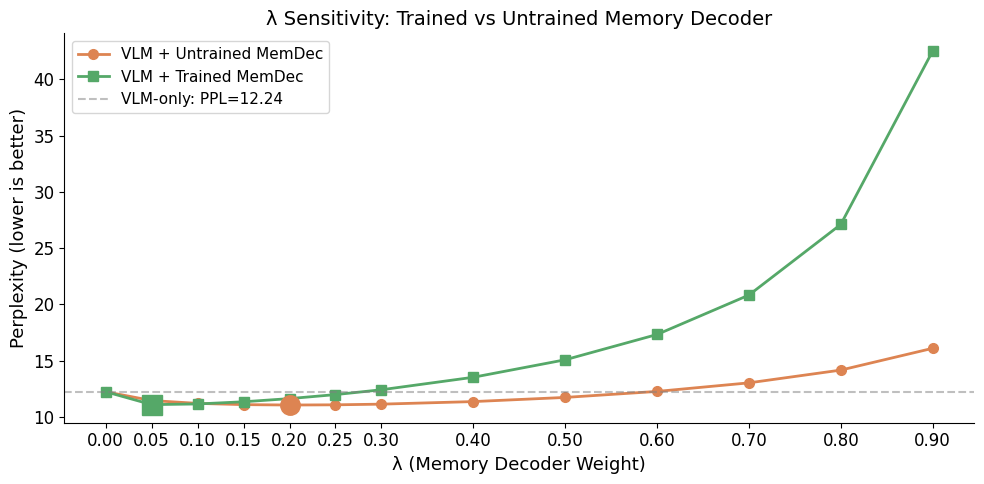


Best untrained: λ=0.2, PPL=11.07
Best trained:   λ=0.05, PPL=11.10


In [27]:
# ============================================================
# 6g. Lambda sweep for trained vs untrained MemDec
# ============================================================
print("Sweeping λ for both trained & untrained MemDec (on 30 samples)...")

ds_sweep = load_dataset("jmhessel/newyorker_caption_contest", "explanation",
                        split="validation", streaming=True)

# Cache logits from all 3 models
cached_3way = []
cnt2 = 0
for sample in tqdm(ds_sweep, desc="Caching logits", total=30):
    image = sample.get("image")
    desc = sample.get("image_description", "")
    if not image or not desc or len(desc.strip()) < 10:
        continue
    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
        {"role": "assistant", "content": [{"type": "text", "text": desc}]},
    ]
    prompt_msgs = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": "Describe what you see in this cartoon."}]},
    ]
    try:
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        inputs = processor(text=[text], images=[image.convert("RGB")], return_tensors="pt", padding=True)
        pt = processor.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
        pi = processor(text=[pt], images=[image.convert("RGB")], return_tensors="pt", padding=True)
    except Exception:
        continue

    inputs_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
    prompt_len = pi["input_ids"].shape[1]
    labels = inputs_dev["input_ids"].clone()
    labels[:, :prompt_len] = -100
    labels = labels[:, 1:]
    nonpad = labels != -100
    if nonpad.sum() == 0:
        continue

    with torch.no_grad():
        out_vlm = vlm(**inputs_dev)
        out_un_mem = untrained_mem_lm(input_ids=inputs_dev["input_ids"],
                                       attention_mask=inputs_dev.get("attention_mask"))
        out_tr_mem = trained_mem_lm(input_ids=inputs_dev["input_ids"],
                                     attention_mask=inputs_dev.get("attention_mask"))

    vv = min(out_vlm.logits.shape[-1], out_un_mem.logits.shape[-1])
    logp_vlm = F.log_softmax(out_vlm.logits[:, :-1, :vv].float(), dim=-1)
    logp_un = F.log_softmax(out_un_mem.logits[:, :-1, :vv].float(), dim=-1)
    logp_tr = F.log_softmax(out_tr_mem.logits[:, :-1, :vv].float(), dim=-1)

    cached_3way.append((logp_vlm[nonpad].cpu(), logp_un[nonpad].cpu(),
                        logp_tr[nonpad].cpu(), labels[nonpad].cpu()))
    cnt2 += 1
    if cnt2 >= 30:
        break

print(f"Cached {len(cached_3way)} samples, sweeping λ ...")

lam_vals = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ppls_untrained_sweep = []
ppls_trained_sweep = []

for lam in lam_vals:
    nll_un_total, nll_tr_total, n_total = 0.0, 0.0, 0
    for logp_v, logp_u, logp_t, labs in cached_3way:
        if lam == 0:
            logp_fused_un = logp_v
            logp_fused_tr = logp_v
        else:
            logp_fused_un = torch.logaddexp(logp_v + math.log(1 - lam), logp_u + math.log(lam))
            logp_fused_tr = torch.logaddexp(logp_v + math.log(1 - lam), logp_t + math.log(lam))
        nll_un_total += F.nll_loss(logp_fused_un.reshape(-1, logp_fused_un.shape[-1]),
                                   labs.reshape(-1), reduction="sum").item()
        nll_tr_total += F.nll_loss(logp_fused_tr.reshape(-1, logp_fused_tr.shape[-1]),
                                   labs.reshape(-1), reduction="sum").item()
        n_total += labs.numel()
    ppls_untrained_sweep.append(math.exp(nll_un_total / n_total))
    ppls_trained_sweep.append(math.exp(nll_tr_total / n_total))

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(lam_vals, ppls_untrained_sweep, 'o-', color='#DD8452', linewidth=2,
        markersize=7, label='VLM + Untrained MemDec')
ax.plot(lam_vals, ppls_trained_sweep, 's-', color='#55A868', linewidth=2,
        markersize=7, label='VLM + Trained MemDec')

best_un_idx = np.argmin(ppls_untrained_sweep)
best_tr_idx = np.argmin(ppls_trained_sweep)
ax.plot(lam_vals[best_un_idx], ppls_untrained_sweep[best_un_idx], 'o',
        color='#DD8452', markersize=14, zorder=5)
ax.plot(lam_vals[best_tr_idx], ppls_trained_sweep[best_tr_idx], 's',
        color='#55A868', markersize=14, zorder=5)

ax.axhline(y=ppls_untrained_sweep[0], color='gray', linestyle='--', alpha=0.5,
           label=f'VLM-only: PPL={ppls_untrained_sweep[0]:.2f}')
ax.set_xlabel('λ (Memory Decoder Weight)', fontsize=13)
ax.set_ylabel('Perplexity (lower is better)', fontsize=13)
ax.set_title('λ Sensitivity: Trained vs Untrained Memory Decoder', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(lam_vals)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nBest untrained: λ={lam_vals[best_un_idx]}, PPL={ppls_untrained_sweep[best_un_idx]:.2f}")
print(f"Best trained:   λ={lam_vals[best_tr_idx]}, PPL={ppls_trained_sweep[best_tr_idx]:.2f}")

In [28]:
# ============================================================
# 6h. Final summary table: 3-way comparison
# ============================================================
summary_3way = f"""
<h3>📊 Training Evaluation Summary</h3>
<table style="width:90%; border-collapse:collapse; margin:auto;">
<tr style="background:#2c3e50; color:white;">
  <th style="padding:10px;border:1px solid #ddd;">Configuration</th>
  <th style="padding:10px;border:1px solid #ddd;">Base Model</th>
  <th style="padding:10px;border:1px solid #ddd;">Memory Decoder</th>
  <th style="padding:10px;border:1px solid #ddd;">Training</th>
  <th style="padding:10px;border:1px solid #ddd;">PPL (↓)</th>
  <th style="padding:10px;border:1px solid #ddd;">Δ vs VLM-only</th>
  <th style="padding:10px;border:1px solid #ddd;">Best λ</th>
</tr>
<tr style="background:#ecf0f1;">
  <td style="padding:10px;border:1px solid #ddd;">VLM only</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;">{ppl_vlm:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
  <td style="padding:10px;border:1px solid #ddd;">—</td>
</tr>
<tr style="background:#fdebd0;">
  <td style="padding:10px;border:1px solid #ddd;">VLM + Untrained</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-0.5B</td>
  <td style="padding:10px;border:1px solid #ddd;">❌ None</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;">{ppl_un:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;color:#27ae60;font-weight:bold;">↓ {ppl_vlm - ppl_un:.2f} ({(ppl_vlm-ppl_un)/ppl_vlm*100:.1f}%)</td>
  <td style="padding:10px;border:1px solid #ddd;">{lam_vals[best_un_idx]}</td>
</tr>
<tr style="background:#d5f5e3;">
  <td style="padding:10px;border:1px solid #ddd;">VLM + Trained</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-VL-2B</td>
  <td style="padding:10px;border:1px solid #ddd;">Qwen2-0.5B</td>
  <td style="padding:10px;border:1px solid #ddd;">✅ KNN distill</td>
  <td style="padding:10px;border:1px solid #ddd;font-weight:bold;color:#27ae60;">{ppl_tr:.2f}</td>
  <td style="padding:10px;border:1px solid #ddd;color:#27ae60;font-weight:bold;">↓ {ppl_vlm - ppl_tr:.2f} ({(ppl_vlm-ppl_tr)/ppl_vlm*100:.1f}%)</td>
  <td style="padding:10px;border:1px solid #ddd;">{lam_vals[best_tr_idx]}</td>
</tr>
</table>
<br>
<p style="text-align:center; color:#555;">
  Dataset: New Yorker Caption Contest (train: 2,340 images, val: {eval_count} images, {total_tok} tokens)<br>
  Training: 15 epochs, α=0.5, lr=1e-3, KNN k=1024
</p>
"""
display(HTML(summary_3way))

Configuration,Base Model,Memory Decoder,Training,PPL (↓),Δ vs VLM-only,Best λ
VLM only,Qwen2-VL-2B,—,—,12.53,—,—
VLM + Untrained,Qwen2-VL-2B,Qwen2-0.5B,❌ None,11.51,↓ 1.02 (8.2%),0.2
VLM + Trained,Qwen2-VL-2B,Qwen2-0.5B,✅ KNN distill,11.90,↓ 0.63 (5.1%),0.05
